In [1]:
# 1. INSTALAÇÃO E IMPORTAÇÃO
!pip install pandas networkx matplotlib
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from google.colab import drive
import os

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
PATH_DRIVE = '/content/drive/MyDrive/Classroom/G_MC859A_2026S1/data/'

print("Carregando os datasets...")
# Carregando os CSVs e forçando os tipos corretos
df_maduro = pd.read_csv(PATH_DRIVE + 'maduro_window_31-12_06-01.csv')
df_khamenei = pd.read_csv(PATH_DRIVE + 'alikhamenei_window_25-02_03-03.csv')
df_baseline = pd.read_csv(PATH_DRIVE + 'baseline_window_16-10_23-10.csv')

Carregando os datasets...


In [4]:
for df in [df_maduro, df_khamenei, df_baseline]:
    df['block_timestamp'] = pd.to_datetime(df['block_timestamp'].str.replace(' UTC', ''))
    df = df[df['receipt_status'] == 1]

In [5]:
janelas = [
    {"nome": "Baseline", "df": df_baseline, "inicio": "2025-10-16", "fim": "2025-10-23 23:59:59"},
    {"nome": "Maduro_1_Antes", "df": df_maduro, "inicio": "2025-12-31", "fim": "2026-01-02 23:59:59"},
    {"nome": "Maduro_2_Choque", "df": df_maduro, "inicio": "2026-01-03 00:00:00", "fim": "2026-01-03 23:59:59"},
    {"nome": "Maduro_3_Depois", "df": df_maduro, "inicio": "2026-01-04 00:00:00", "fim": "2026-01-06 23:59:59"},
    {"nome": "Khamenei_1_Antes", "df": df_khamenei, "inicio": "2026-02-25", "fim": "2026-02-27 23:59:59"},
    {"nome": "Khamenei_2_Choque", "df": df_khamenei, "inicio": "2026-02-28 00:00:00", "fim": "2026-02-28 23:59:59"},
    {"nome": "Khamenei_3_Depois", "df": df_khamenei, "inicio": "2026-03-01 00:00:00", "fim": "2026-03-03 23:59:59"}
]



In [6]:
# FUNÇÃO DE ANÁLISE E PLOTAGEM
metricas_projeto = []

def analisar_e_exportar(nome, df, data_inicio, data_fim):
    print(f"\n--- Processando: {nome} ---")
    mask = (df['block_timestamp'] >= data_inicio) & (df['block_timestamp'] <= data_fim)
    df_slice = df.loc[mask]

    if df_slice.empty:
        print("Grafo vazio.")
        return

    edges = df_slice.groupby(['source_node', 'target_node'])['edge_weight'].sum().reset_index()

    # Criando grafo Direcionado
    G = nx.from_pandas_edgelist(edges, source='source_node', target='target_node', edge_attr='edge_weight', create_using=nx.DiGraph())
    G.remove_edges_from(list(nx.selfloop_edges(G)))

    # Exportando o .graphml para a pasta do Drive
    caminho_graphml = PATH_DRIVE + f"{nome}.graphml"
    nx.write_graphml(G, caminho_graphml)
    print(f"Salvo: {caminho_graphml}")

    # --- CÁLCULO DAS MÉTRICAS DO PROFESSOR ---
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()

    # Grau médio: em grafos direcionados, soma de in_degree + out_degree / num_nodes
    graus = dict(G.degree())
    grau_medio = sum(graus.values()) / num_nodes

    # Componentes Fortemente Conexos (SCC)
    sccs = list(nx.strongly_connected_components(G))
    num_sccs = len(sccs)
    tamanhos_sccs = [len(c) for c in sccs]

    metricas_projeto.append({
        "Instância": nome,
        "Vértices": num_nodes,
        "Arestas": num_edges,
        "Grau Médio": round(grau_medio, 2),
        "Qtd Comp. Fort. Conexas (SCC)": num_sccs,
        "Tamanho da Maior SCC": max(tamanhos_sccs) if tamanhos_sccs else 0
    })

    # --- GERAÇÃO DOS GRÁFICOS ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico 1: Distribuição de Graus (Em escala log-log, ideal para redes complexas)
    contagem_graus = Counter(graus.values())
    x_graus, y_graus = zip(*sorted(contagem_graus.items()))
    ax1.scatter(x_graus, y_graus, alpha=0.7, color='b', edgecolors='black')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_title(f'Distribuição de Graus\n({nome})')
    ax1.set_xlabel('Grau do Vértice (k)')
    ax1.set_ylabel('Frequência')
    ax1.grid(True, which="both", ls="--", alpha=0.5)

    # Gráfico 2: Distribuição dos Tamanhos das Componentes Fortemente Conexas
    if num_sccs > 1:
        contagem_sccs = Counter(tamanhos_sccs)
        x_sccs, y_sccs = zip(*sorted(contagem_sccs.items()))
        ax2.scatter(x_sccs, y_sccs, alpha=0.7, color='r', edgecolors='black')
        ax2.set_xscale('log')
        ax2.set_yscale('log')
        ax2.set_title(f'Distribuição do Tamanho das SCCs\n({nome})')
        ax2.set_xlabel('Tamanho da Componente (k vértices)')
        ax2.set_ylabel('Quantidade de Componentes')
        ax2.grid(True, which="both", ls="--", alpha=0.5)
    else:
        ax2.text(0.5, 0.5, 'Apenas 1 Componente Conexa', ha='center', va='center')
        ax2.axis('off')

    plt.tight_layout()
    # Salva a imagem na sua pasta do Drive
    caminho_imagem = PATH_DRIVE + f"graficos_{nome}.png"
    plt.savefig(caminho_imagem)
    plt.show()


--- Processando: Baseline ---
Salvo: /content/drive/MyDrive/Classroom/G_MC859A_2026S1/data/Baseline.graphml


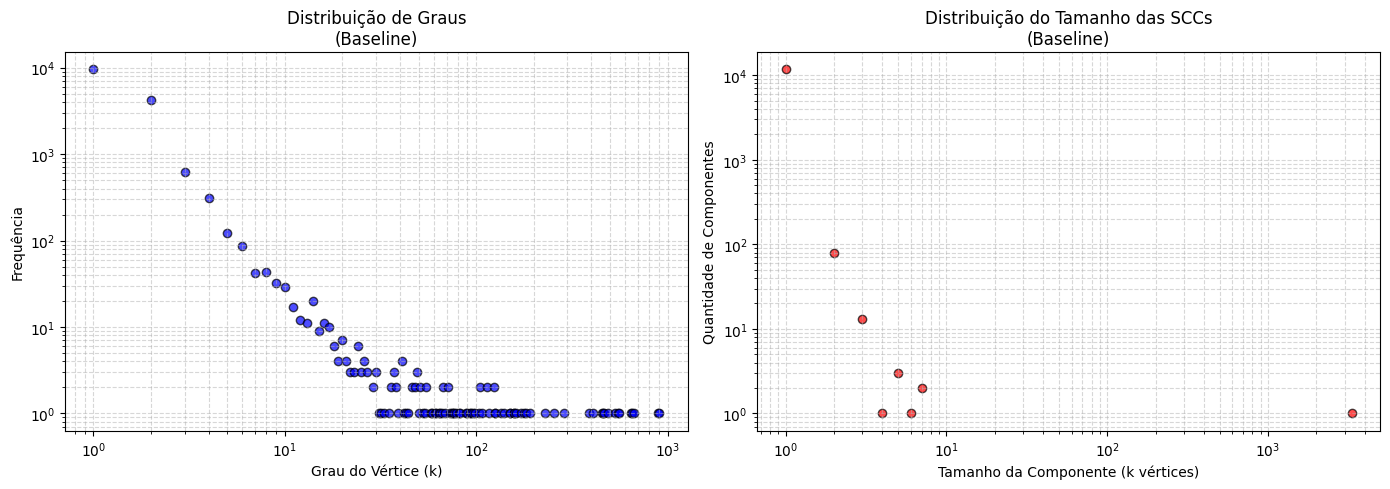


--- Processando: Maduro_1_Antes ---
Salvo: /content/drive/MyDrive/Classroom/G_MC859A_2026S1/data/Maduro_1_Antes.graphml


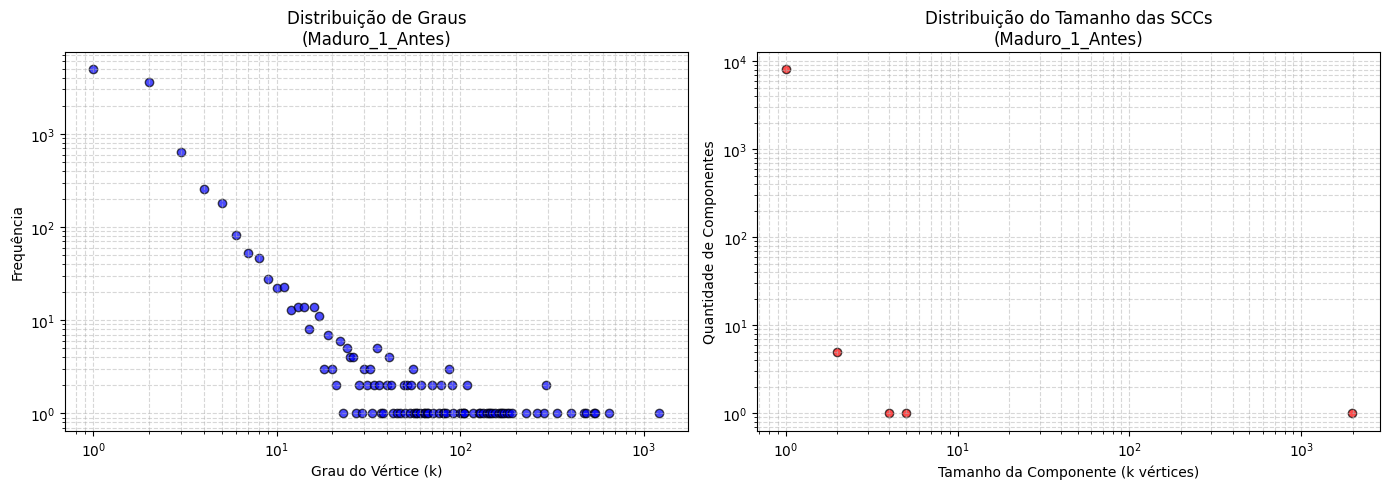


--- Processando: Maduro_2_Choque ---
Salvo: /content/drive/MyDrive/Classroom/G_MC859A_2026S1/data/Maduro_2_Choque.graphml


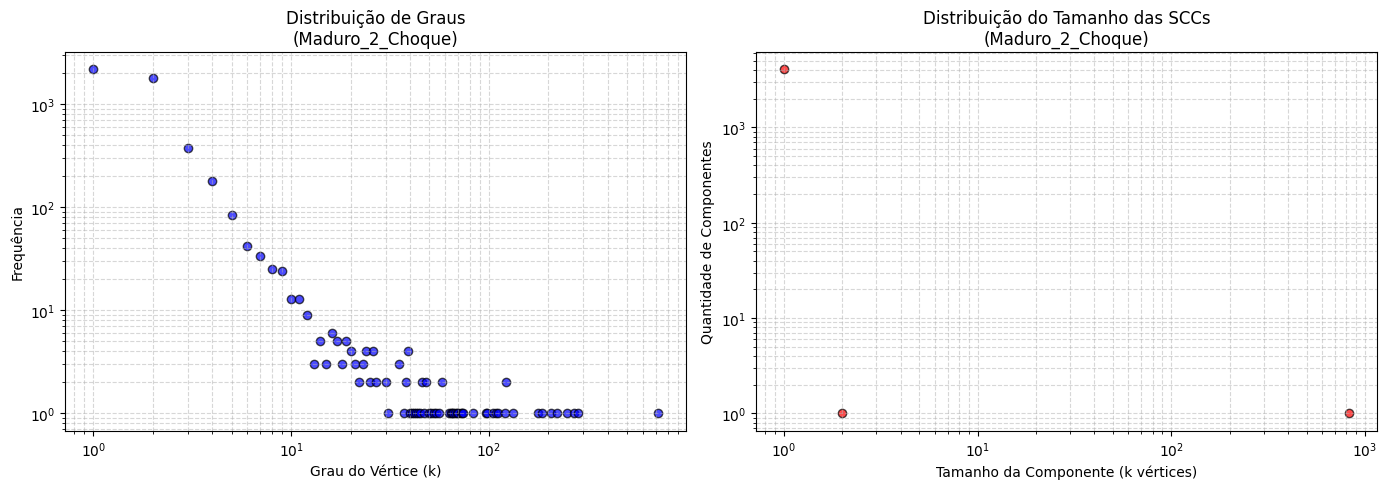


--- Processando: Maduro_3_Depois ---
Salvo: /content/drive/MyDrive/Classroom/G_MC859A_2026S1/data/Maduro_3_Depois.graphml


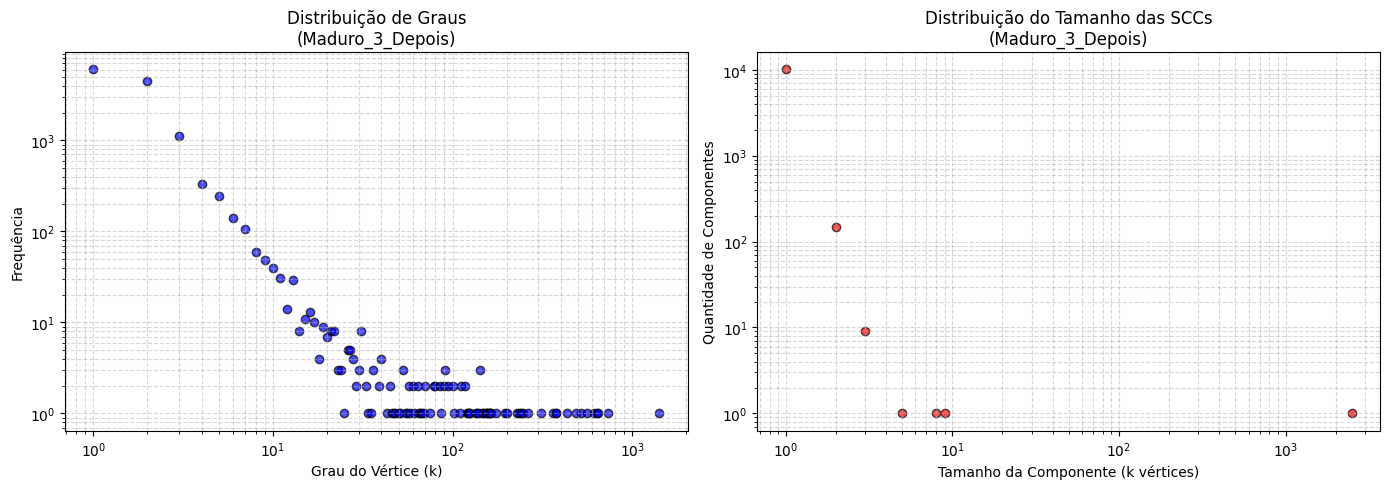


--- Processando: Khamenei_1_Antes ---
Salvo: /content/drive/MyDrive/Classroom/G_MC859A_2026S1/data/Khamenei_1_Antes.graphml


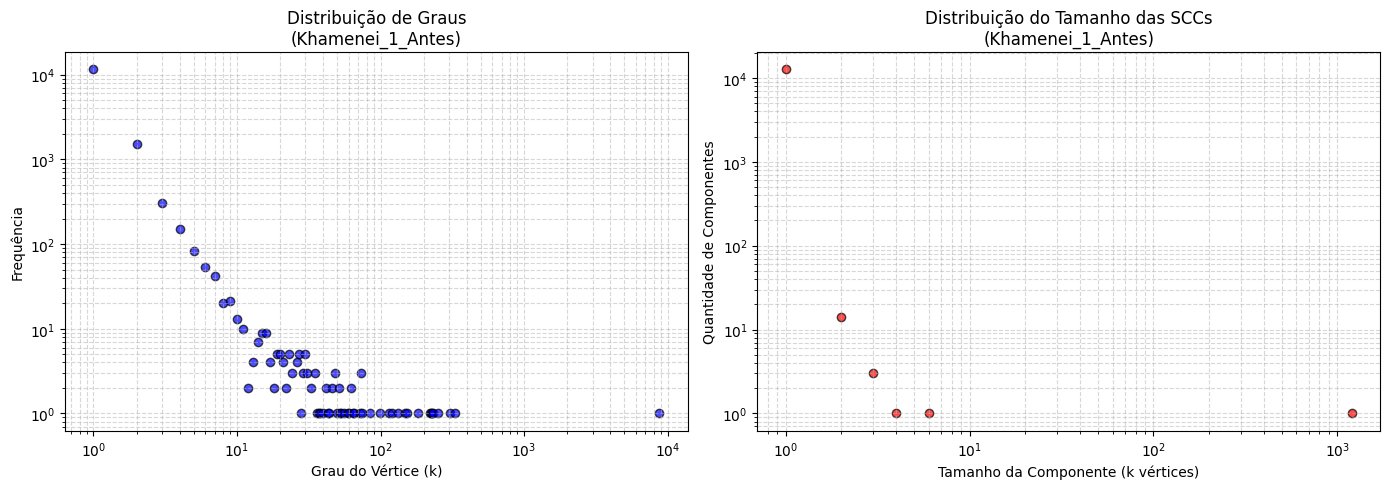


--- Processando: Khamenei_2_Choque ---
Salvo: /content/drive/MyDrive/Classroom/G_MC859A_2026S1/data/Khamenei_2_Choque.graphml


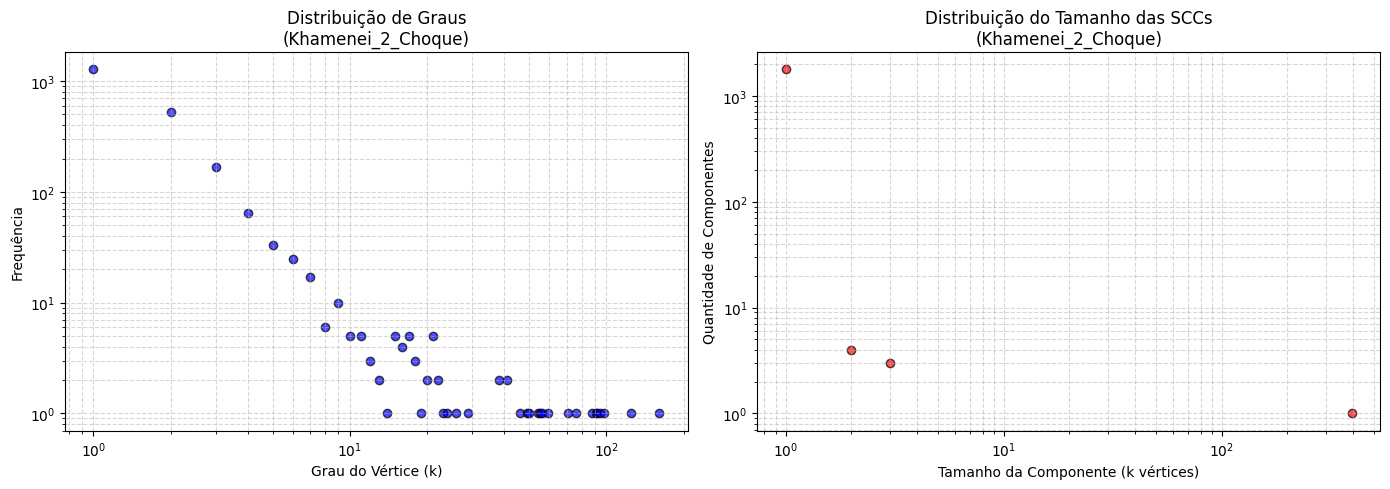


--- Processando: Khamenei_3_Depois ---
Salvo: /content/drive/MyDrive/Classroom/G_MC859A_2026S1/data/Khamenei_3_Depois.graphml


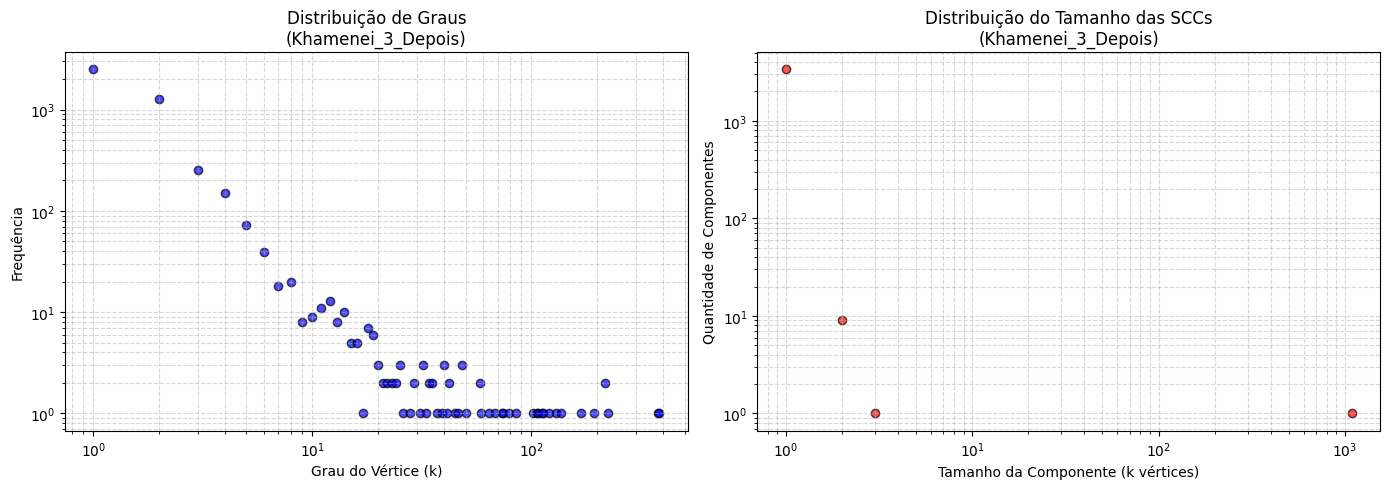


=== RESUMO DAS MÉTRICAS PARA O RELATÓRIO ===


,Instância,Vértices,Arestas,Grau Médio,Qtd Comp. Fort. Conexas (SCC),Tamanho da Maior SCC
0,Baseline,15311,20478,2.67,11859,3315
1,Maduro_1_Antes,10035,16204,3.23,8057,1967
2,Maduro_2_Choque,4901,7901,3.22,4075,826
3,Maduro_3_Depois,12947,21637,3.34,10268,2495
4,Khamenei_1_Antes,13910,16396,2.36,12683,1200
5,Khamenei_2_Choque,2199,2932,2.67,1795,395
6,Khamenei_3_Depois,4481,6525,2.91,3385,1086


In [7]:
for j in janelas:
    analisar_e_exportar(j['nome'], j['df'], j['inicio'], j['fim'])

print("\n=== RESUMO DAS MÉTRICAS PARA O RELATÓRIO ===")
df_metricas = pd.DataFrame(metricas_projeto)
display(df_metricas)

# Salva a tabela também no drive
df_metricas.to_csv(PATH_DRIVE + 'tabela_metricas_parcial.csv', index=False)